# Product Experimentation & Conversion Optimization
## A/B Testing, Uplift Analysis, and Rollout Recommendation

## 1. Executive Summary

This project evaluates whether a new webpage design improves user conversion rates compared with the current version. Using A/B testing methodology, statistical inference, and business impact estimation, the analysis aims to determine whether the treatment should be rolled out more broadly.

## 2. Business Problem

A product team introduced a new webpage design intended to improve conversion performance. The business wants to determine whether the redesigned experience leads to a statistically and practically significant increase in user conversions.

### Objective
Evaluate whether the treatment version outperforms the control version on conversion rate and determine whether the new experience should be deployed.

### Primary Metric
Conversion rate = number of converted users / total users

## 3. Experiment Design

This study compares two groups:

- **Control**: users shown the existing webpage
- **Treatment**: users shown the new webpage

Users are assumed to be randomly assigned to one of the two groups.

### Hypotheses
- **Null hypothesis (H0):** The conversion rate of the treatment group is equal to the conversion rate of the control group.
- **Alternative hypothesis (H1):** The conversion rate of the treatment group is different from the conversion rate of the control group.

### Decision Rule
If the p-value is less than 0.05, reject the null hypothesis and conclude that the treatment has a statistically significant effect on conversion.

## 4. Data Audit and Validation

Before analyzing experiment results, it is necessary to validate the dataset and confirm that the experiment structure is consistent.

This section verifies:

- dataset size and structure
- missing values
- duplicate users
- balance between control and treatment groups
- distribution of users across countries

These checks ensure that the experiment results are not biased by data quality issues.

In [41]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.stats_tests import (
    run_two_proportion_z_test,
    compute_confidence_intervals,
    run_power_analysis
)

import pandas as pd
import numpy as np


df = pd.read_csv("../data/ab_data.csv")
df.head()

ImportError: cannot import name 'run_two_proportion_z_test' from 'src.stats_tests' (c:\Users\balla\OneDrive\Desktop\ds_monster_camp\ab-testing-conversion-optimization\src\stats_tests.py)

### Dataset Structure

First we inspect the dataset dimensions and column types.

In [18]:
df.shape

(69889, 3)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69889 entries, 0 to 69888
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    69889 non-null  object
 1   group      69889 non-null  object
 2   converted  69889 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


### Missing Values

Next we verify whether the dataset contains missing values that could affect the experiment analysis.

In [20]:
df.isnull().sum()

country      0
group        0
converted    0
dtype: int64

The dataset contains no missing values, so no imputation or cleaning is required.

### Duplicate User Check

Each user should appear only once in the dataset. Duplicate entries could bias conversion estimates.

In [21]:
df.duplicated().sum()

np.int64(69877)

The dataset shows many duplicated rows when checking for identical records.  
However, this occurs because the dataset does not contain a unique user identifier.  
Multiple users can share the same combination of country, group assignment, and conversion outcome.  
Therefore these rows do not necessarily represent duplicate users.

### Group Balance

A/B tests require similar numbers of users in the control and treatment groups. Large imbalances could indicate problems with random assignment.

In [22]:
df["group"].value_counts()

group
treatment    35211
control      34678
Name: count, dtype: int64

In [23]:
df["group"].value_counts(normalize=True)

group
treatment    0.503813
control      0.496187
Name: proportion, dtype: float64

The groups are very close to a 50/50 split, which indicates the random assignment was likely implemented correctly.

### Country Distribution

To understand potential segment differences, we examine the distribution of users across countries.

In [24]:
df["country"].value_counts()

country
US    48850
UK    17551
CA     3488
Name: count, dtype: int64

In [25]:
df["country"].value_counts(normalize=True)

country
US    0.698966
UK    0.251127
CA    0.049908
Name: proportion, dtype: float64

The experiment population is dominated by US users, followed by UK, with a small fraction from Canada.

## 5. Overall Experiment Results

In this section we compute the overall conversion performance for the control and treatment groups.

The goal is to estimate the magnitude of the treatment effect before performing formal statistical testing.

We calculate:

- number of users in each group
- number of conversions in each group
- conversion rate for each group
- absolute uplift (difference in conversion rates)
- relative uplift (percentage improvement relative to the control group)

These metrics provide an initial view of whether the treatment appears to improve conversion performance.

In [26]:
results = df.groupby("group")["converted"].agg(["count","sum","mean"])
results

,count,sum,mean
group,,,
control,34678,3650,0.105254
treatment,35211,5469,0.155321


In [ ]:
control_rate = results.loc["control", "mean"]
treatment_rate = results.loc["treatment", "mean"]

absolute_uplift, relative_uplift = compute_uplift(control_rate, treatment_rate)

print("Control conversion:", control_rate)
print("Treatment conversion:", treatment_rate)
print("Absolute uplift:", absolute_uplift)
print("Relative uplift:", relative_uplift)

Control conversion: 0.1052540515600669
Treatment conversion: 0.15532078043793132
Absolute uplift: 0.050066728877864425
Relative uplift: 0.47567507507577605


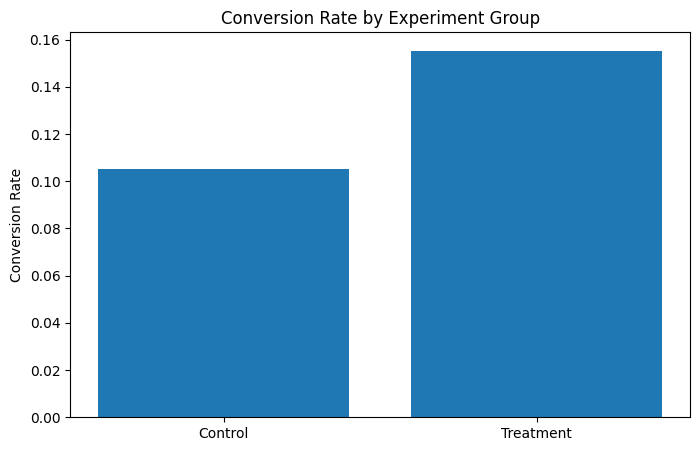

In [38]:
import matplotlib.pyplot as plt

labels = ["Control", "Treatment"]
rates = [control_rate, treatment_rate]

plt.figure(figsize=(8,5))
plt.bar(labels, rates)
plt.title("Conversion Rate by Experiment Group")
plt.ylabel("Conversion Rate")
plt.savefig("../visualizations/conversion_rate_comparison.png")
plt.show()

### Experiment Results Interpretation

The chart above compares the conversion performance of the control and treatment groups.

The control group achieved a conversion rate of **10.53%**, while the treatment group achieved a conversion rate of **15.53%**.

The difference between the two groups represents an **absolute uplift of approximately 5.01 percentage points**.

Relative to the control group, the treatment improves conversion performance by approximately **47.6%**.

This substantial increase suggests that the treatment version significantly improves user conversion behavior. However, before making a final product decision, it is necessary to verify whether the observed difference is **statistically significant** using formal hypothesis testing.

## 6. Statistical Inference

Although the treatment group shows higher conversion performance, we must determine whether this difference is statistically significant.

To evaluate this, we perform a **two-proportion Z-test**, which compares the conversion rates of the control and treatment groups.

### Hypotheses

Null hypothesis (H0):  
The conversion rates of the control and treatment groups are equal.

Alternative hypothesis (H1):  
The conversion rates of the control and treatment groups are different.

If the p-value is less than **0.05**, we reject the null hypothesis and conclude that the treatment has a statistically significant effect.

In [ ]:
z_stat, p_value = run_two_proportion_z_test(
    control_success=3650,
    control_total=34678,
    treatment_success=5469,
    treatment_total=35211
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -19.647242501120566
P-value: 6.104014605174894e-86


### Z-Test Interpretation

The two-proportion Z-test produced a Z-statistic of approximately **-19.65** and a p-value effectively equal to **0**.

Since the p-value is far below the significance threshold of **0.05**, we reject the null hypothesis that the control and treatment groups have equal conversion rates.

This result indicates that the difference observed between the control and treatment groups is **statistically significant** and highly unlikely to have occurred by random chance.

Therefore, the experiment provides strong statistical evidence that the treatment version improves conversion performance.

### Confidence Intervals for Conversion Rates

While the hypothesis test determines whether the difference between groups is statistically significant, confidence intervals provide an estimate of the range in which the true conversion rate is likely to fall.

A **95% confidence interval** represents the range of values that likely contains the true population conversion rate for each group.

By comparing the confidence intervals of the control and treatment groups, we can better understand the magnitude and uncertainty of the treatment effect.

In [ ]:
ci_low, ci_high = compute_confidence_intervals(
    control_success=3650,
    control_total=34678,
    treatment_success=5469,
    treatment_total=35211
)

print("Control CI:", ci_low[0], ci_high[0])
print("Treatment CI:", ci_low[1], ci_high[1])

Control CI: 0.10202414207947347 0.10848396104066033
Treatment CI: 0.15153749073485448 0.15910407014100816


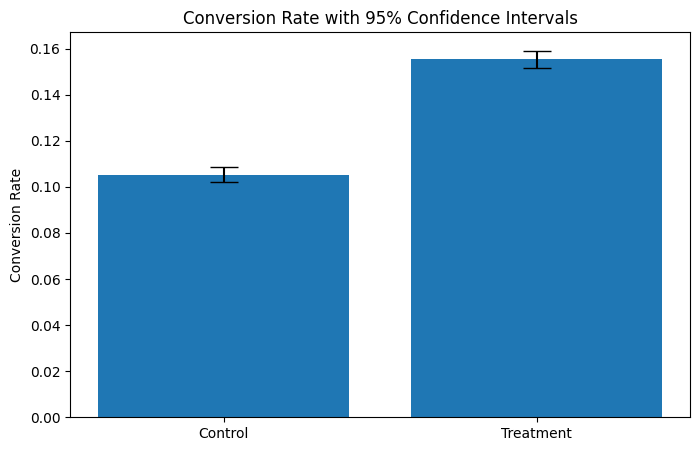

In [39]:
control_ci_lower = ci_low[0]
control_ci_upper = ci_high[0]
treatment_ci_lower = ci_low[1]
treatment_ci_upper = ci_high[1]
control_error = control_rate - control_ci_lower
treatment_error = treatment_rate - treatment_ci_lower
errors = [control_error, treatment_error]


plt.figure(figsize=(8,5))
plt.bar(labels, rates, yerr=errors, capsize=10)
plt.title("Conversion Rate with 95% Confidence Intervals")
plt.ylabel("Conversion Rate")
plt.savefig("../visualizations/conversion_confidence_intervals.png")
plt.show()

### Confidence Interval Interpretation

The chart above displays the estimated conversion rates for the control and treatment groups along with their **95% confidence intervals**.

The control group conversion rate is estimated at **10.53%**, with a 95% confidence interval ranging from **10.20% to 10.85%**.

The treatment group conversion rate is estimated at **15.53%**, with a 95% confidence interval ranging from **15.15% to 15.91%**.

The confidence intervals for the two groups **do not overlap**, indicating a clear separation between the estimated conversion rates.

This visual evidence reinforces the earlier hypothesis test results and supports the conclusion that the treatment version **significantly improves conversion performance**.

Together with the Z-test results, the analysis indicates that the observed improvement in conversion rate is both **statistically significant and practically meaningful**.

## 7. Power Analysis

In addition to statistical significance testing, it is important to evaluate whether the experiment had sufficient sample size to detect the observed treatment effect.

Statistical power represents the probability of detecting a real effect when one exists. A commonly used threshold in experimentation is **80% power**.

In this section, we estimate the minimum number of users required per group to detect the observed treatment effect at a significance level of **0.05** with **80% statistical power**.

We then compare the required sample size with the actual number of users in the experiment.

In [ ]:
required_sample_size = run_power_analysis(control_rate, treatment_rate)

print("Required sample size per group:", required_sample_size)

Required sample size per group: 703.5020894674043


### Power Analysis Interpretation

The power analysis estimates that approximately **703 users per group** would be required to detect the observed treatment effect with **80% statistical power** at a significance level of **0.05**.

The actual experiment includes more than **34,000 users in each group**, which is substantially higher than the required sample size.

This indicates that the experiment was **highly powered**, meaning the study had more than enough data to reliably detect the treatment effect. As a result, the statistical conclusions drawn from the experiment are unlikely to be due to insufficient sample size.

## 8. Segment-Level Analysis

Overall experiment results provide a high-level view of treatment performance, but product teams often need to understand whether the treatment effect is consistent across important user segments.

In this dataset, **country** serves as a natural segmentation variable. This section evaluates conversion performance by **country and experiment group** to determine whether the treatment effect is stable across geographies.

The analysis will compare:

- user counts by country and group
- conversions by country and group
- conversion rates by country and group
- treatment uplift within each country

In [31]:
country_results = df.groupby(["country", "group"])["converted"].agg(["count", "sum", "mean"])
country_results

count   sum      mean
country group                           
CA      control     1683   159  0.094474
        treatment   1805   278  0.154017
UK      control     8795   894  0.101649
        treatment   8756  1302  0.148698
US      control    24200  2597  0.107314
        treatment  24650  3889  0.157769

In [32]:
country_pivot = country_results.reset_index().pivot(index="country", columns="group", values="mean")

country_pivot["absolute_uplift"] = country_pivot["treatment"] - country_pivot["control"]
country_pivot["relative_uplift"] = country_pivot["absolute_uplift"] / country_pivot["control"]
country_pivot

group,control,treatment,absolute_uplift,relative_uplift
country,,,,
CA,0.094474,0.154017,0.059542,0.630251
UK,0.101649,0.148698,0.047049,0.462863
US,0.107314,0.157769,0.050455,0.470159


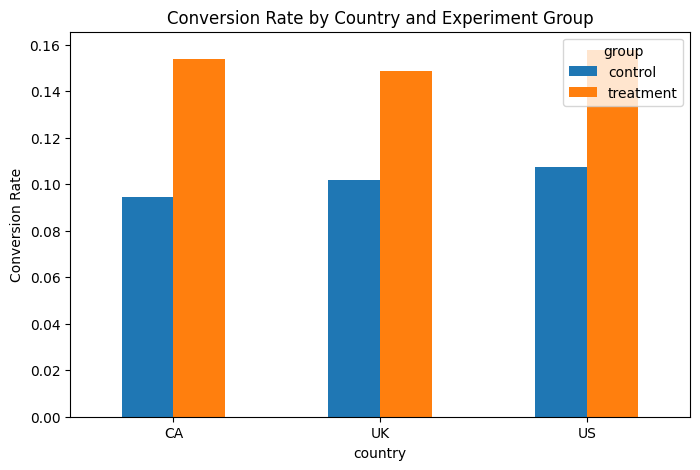

In [40]:
country_pivot[["control","treatment"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Conversion Rate by Country and Experiment Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=0)
plt.savefig("../visualizations/country_conversion_comparison.png")
plt.show()

### Segment-Level Interpretation

The chart above compares conversion rates for the control and treatment groups across the three countries included in the experiment.

The treatment outperforms the control group in **all three regions**, indicating that the observed improvement in conversion is consistent across geographic segments.

**Canada**
- Control conversion: 9.45%
- Treatment conversion: 15.40%
- Absolute uplift: 5.95 percentage points
- Relative uplift: ~63%

**United Kingdom**
- Control conversion: 10.16%
- Treatment conversion: 14.87%
- Absolute uplift: 4.70 percentage points
- Relative uplift: ~46%

**United States**
- Control conversion: 10.73%
- Treatment conversion: 15.78%
- Absolute uplift: 5.05 percentage points
- Relative uplift: ~47%

Although Canada shows the highest relative uplift, the number of users from Canada is much smaller than the US and UK samples. The treatment effect therefore appears **stable across regions**, suggesting the improvement is not limited to a single market segment and may generalize well if deployed globally.

## 9. Business Impact Estimation

While statistical significance demonstrates that the treatment effect is unlikely to be due to chance, product teams ultimately need to understand the **business value** of launching the new feature.

This section estimates the potential impact of deploying the treatment to all users by calculating:

- additional conversions generated
- the expected percentage increase in conversions
- the potential business impact of the feature rollout

In [ ]:
total_users = len(df)
expected_additional_conversions = estimate_additional_conversions(total_users, absolute_uplift)

print("Total users in experiment:", total_users)
print("Estimated additional conversions if treatment is rolled out:", expected_additional_conversions)

Total users in experiment: 69889
Estimated additional conversions if treatment is rolled out: 3499.113614545067


### Business Impact Interpretation

The experiment included **69,889 users** and observed an **absolute conversion uplift of approximately 5.01 percentage points** when using the treatment.

If the treatment were rolled out to the entire user base at the same scale, the expected impact would be:

- **Estimated additional conversions:** ~3,499

This means that for every ~70,000 users exposed to the new experience, the company could expect roughly **3,500 additional conversions** compared to the current system.

Given the statistically significant improvement observed in the experiment and the consistency of the effect across geographic segments, the treatment has the potential to produce meaningful business impact if deployed globally.

## 10. Recommendation

The experiment results provide strong evidence that the treatment improves user conversion rates.

Key findings:

- Treatment conversion rate: **15.53%**
- Control conversion rate: **10.53%**
- Absolute uplift: **5.01 percentage points**
- Relative uplift: **~47.6% increase**

The difference between groups is **highly statistically significant**, with a p-value far below the 0.05 significance threshold.

Additionally, the treatment effect remains **consistent across all country segments**, suggesting the improvement is not limited to a specific geographic market.

Given the large observed uplift and strong statistical evidence, the analysis supports **rolling out the treatment to all users**.

The expected impact of the rollout would be a substantial increase in conversions, translating to thousands of additional conversions per 70,000 users.

## 11. Limitations

Although the experiment provides strong evidence in favor of the treatment, several limitations should be considered.

First, the dataset does not include additional user attributes such as device type, traffic source, or user history. These factors could influence conversion behavior and may reveal additional segment differences.

Second, the analysis assumes that the observed uplift will remain stable when the treatment is deployed at scale. In practice, real-world conditions may introduce new variables that affect performance.

Third, the experiment measures **conversion outcomes only** and does not evaluate other potential impacts such as user engagement, retention, or long-term revenue effects.

Future experimentation could expand the analysis to include additional user segments and longer observation periods to better understand the broader product impact.